In [1]:
import torch
import torchquad
import matplotlib.pyplot as plt

from common import *

In [20]:
def TT_wide(si, li, pzi, sf, lf, pzf, kp, y, tin, tout):
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)

    tint1 = Kprime(kp, pzi, pzf, tin, tout) / F0
    denominator = 1j * (omega - kz + 1j * eps)
    tint0 = (2 * torch.exp(1j * (omega - kz) * tin)) / denominator - \
            (2 * torch.exp(1j * (omega - kz) * tout)) / denominator

    term1 = Im1(si, li, sf, lf, y) * tint1
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0
    term3 = Ip1(si, li, sf, lf, y) * tint1

    return torch.stack([term1, term2, term3])

def TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, y, tin, tout, gl):
    # Преобразуем скалярные si, li, sf, lf в int для передачи в функции,
    # которые могут ожидать обычные числа (хотя лучше, если они тоже работают с тензорами).
    si, li, sf, lf = int(si), int(li), int(sf), int(lf)

    # Вычисляем константы один раз
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)


    # --- Создаем ЕДИНУЮ векторизованную подынтегральную функцию ---
    def unified_integrand(t_batch, mode):
        # t_batch имеет форму [N, 1], преобразуем в [N] для удобства
        t = t_batch.squeeze(-1)

        # --- Векторизованные вычисления! Нет циклов! Все операции - torch.* ---
        En_i = En(si, li, pzi, t, HtoHc, sign, F0, m)
        En_f = En(sf, lf, pzf, t, HtoHc, sign, F0, m)
        z_i = z(si, li, pzi, t, HtoHc, sign, F0, m)
        z_f = z(sf, lf, pzf, t, HtoHc, sign, F0, m)

        # Общие части для обоих интегралов
        # Добавляем eps для численной стабильности, чтобы избежать деления на ноль
        eps = 1e-30
        prefactor_common = 1.0 / torch.sqrt(torch.clamp(En_i * En_f, min=eps))

        z_diff_sq = (z_i - z_f) ** 2
        exp1 = torch.exp(-z_diff_sq / (4 * sigma**2))

        int_en_diff = IntEn(si, li, pzi, t, HtoHc, sign, F0, m) - IntEn(
            sf, lf, pzf, t, HtoHc, sign, F0, m
        )
        z_sum = z_i + z_f
        phase = omega * t - int_en_diff - z_sum * (pzf - pzi + kz) / 2.0
        exp2 = torch.exp(1j * phase)

        # Различающиеся части
        if mode == "integrand1":
            # Для tint1_Texact у нас просто 1.0 в качестве множителя
            # (но мы оставим его для общности)
            numerator = torch.ones_like(t, dtype=torch.complex128)
        elif mode == "integrand0":
            # Для tint0_Texact
            numerator = -pzi - pzf - 2 * F0 * t + 1j * (z_i - z_f) / sigma**2
        else:
            raise ValueError("Unknown mode")

        return numerator * prefactor_common * exp1 * exp2
        # --- Вычисляем интегралы ---
    # Используем lambda-функции, чтобы передать параметр 'mode' в наш унифицированный интегранд

    # Интеграл для tint1
    tint1_Texact = gl.integrate(
        lambda t: unified_integrand(t, mode="integrand1"),
        dim=1,
        N=101,
        integration_domain=[[tin, tout]],
        
    )

    tint1_Texact_201 = gl.integrate(
    lambda t: unified_integrand(t, mode="integrand1"),
    dim=1,
    N=201,
    integration_domain=[[tin, tout]]
   )

    # Интеграл для tint0
    tint0_Texact = gl.integrate(
        lambda t: unified_integrand(t, mode="integrand0"),
        dim=1,
        N=101,
        integration_domain=[[tin, tout]],
        
    )

    tint0_Texact_201 = gl.integrate(
        lambda t: unified_integrand(t, mode="integrand0"),
        dim=1,
        N=201,
        integration_domain=[[tin, tout]],
        
    )

    # Собираем результат так же, как и раньше
    term1 = Im1(si, li, sf, lf, y) * tint1_Texact
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0_Texact
    term3 = (
        Ip1(si, li, sf, lf, y) * tint1_Texact
    ) 

    tint1_error = torch.abs(tint1_Texact_201 - tint1_Texact)
    tint1_error_2 = torch.abs(tint1_Texact_201 - tint1_Texact) / torch.abs(tint1_Texact_201)
    tint0_error = torch.abs(tint0_Texact_201 - tint0_Texact)
    tint0_error_2 = torch.abs(tint0_Texact_201 - tint0_Texact) / torch.abs(tint0_Texact_201)
    
    return torch.stack([term1, term2, term3]), tint1_error, tint0_error, tint1_error_2, tint0_error_2

   


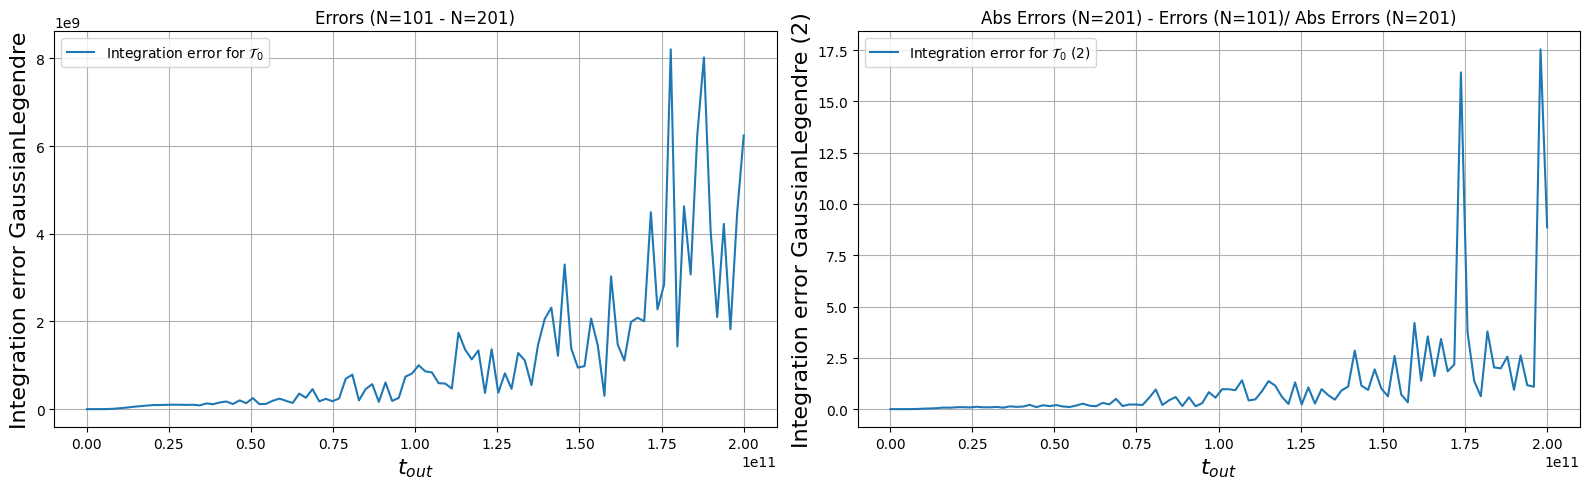

In [32]:

tspec = np.linspace (1.32e8, 2e11, 100)
t_spec = [1.32e8, 1e9]  
# Sweep over tspec and collect errors
tint0_error_list = []
tint0_error_list_2 = []
tint0_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())[0][1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li , sf, lf, kp*rho_H)) for T in tspec]

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())[0][0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]

for T in tspec:
    _, _, tint0_error, _, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    _, tint1_error, _, _, _,= TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    tint0_error_list.append(tint0_error.item() if hasattr(tint0_error, 'item') else float(tint0_error))

    _, _, _, _,tint0_error_2 = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    _, _, _,tint1_error_2, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    tint0_error_list_2.append(tint0_error_2.item() if hasattr(tint0_error_2, 'item') else float(tint0_error_2))

    #print("Estimated error for tint1_Texact:", tint1_error)
    #print("Estimated error for tint0_Texact:", tint0_error)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Первый график
ax1.plot(tspec, tint0_error_list, label='Integration error for $\\mathcal{T}_0$')
ax1.set_xlabel('$t_{out}$', fontsize=16)
ax1.set_ylabel('Integration error GaussianLegendre', fontsize=16)
ax1.grid()
ax1.legend()
ax1.set_title('Errors (N=101 - N=201)')

# Второй график
ax2.plot(tspec, tint0_error_list_2, label='Integration error for $\\mathcal{T}_0$ (2)')
ax2.set_xlabel('$t_{out}$', fontsize=16)
ax2.set_ylabel('Integration error GaussianLegendre (2)', fontsize=16)
ax2.grid()
ax2.legend()
ax2.set_title('Abs Errors (N=201) - Errors (N=101)/ Abs Errors (N=201)')

plt.tight_layout()
plt.show()


/home/ulyana/Itmo/.venv/lib/python3.12/site-packages/autoray/autoray.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/home/ulyana/Itmo/.venv/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


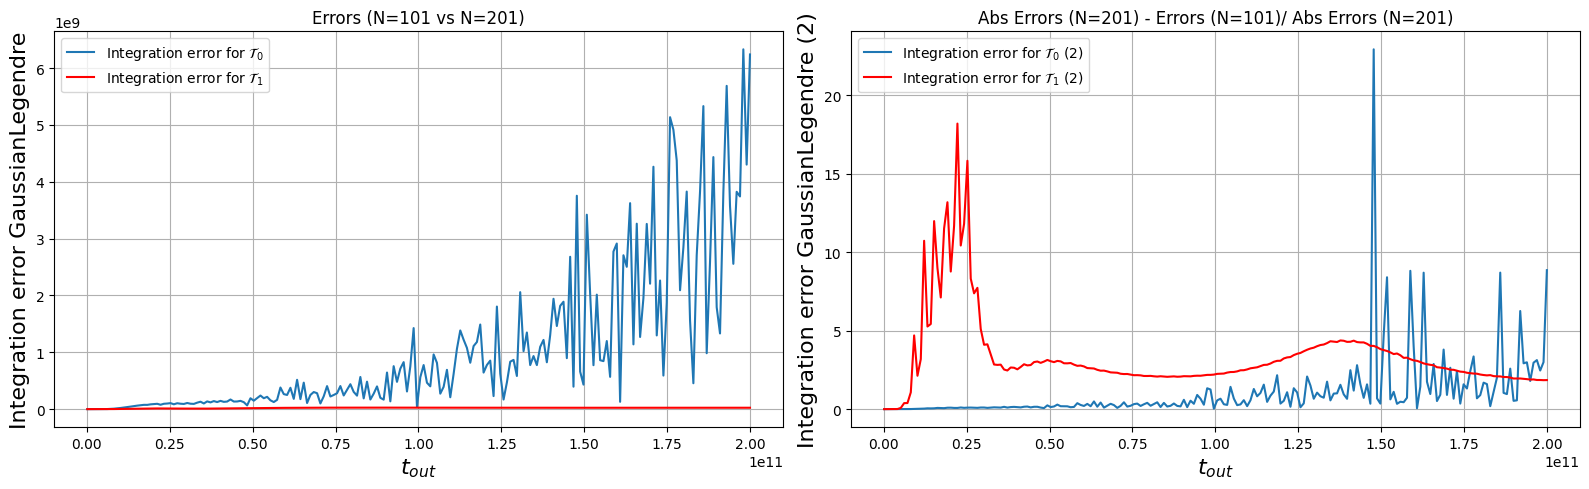

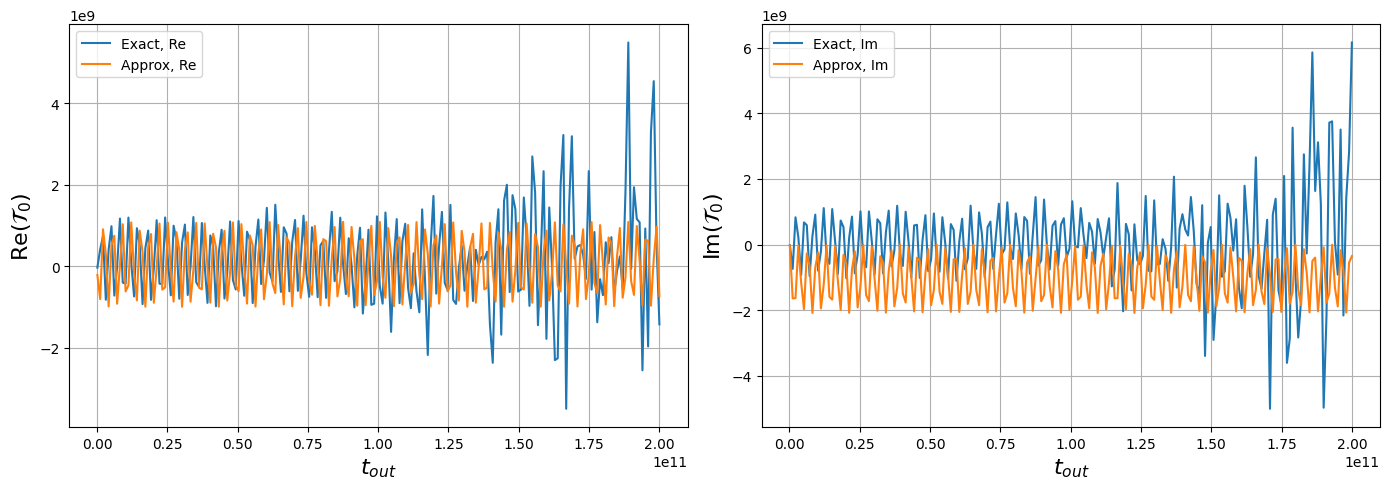

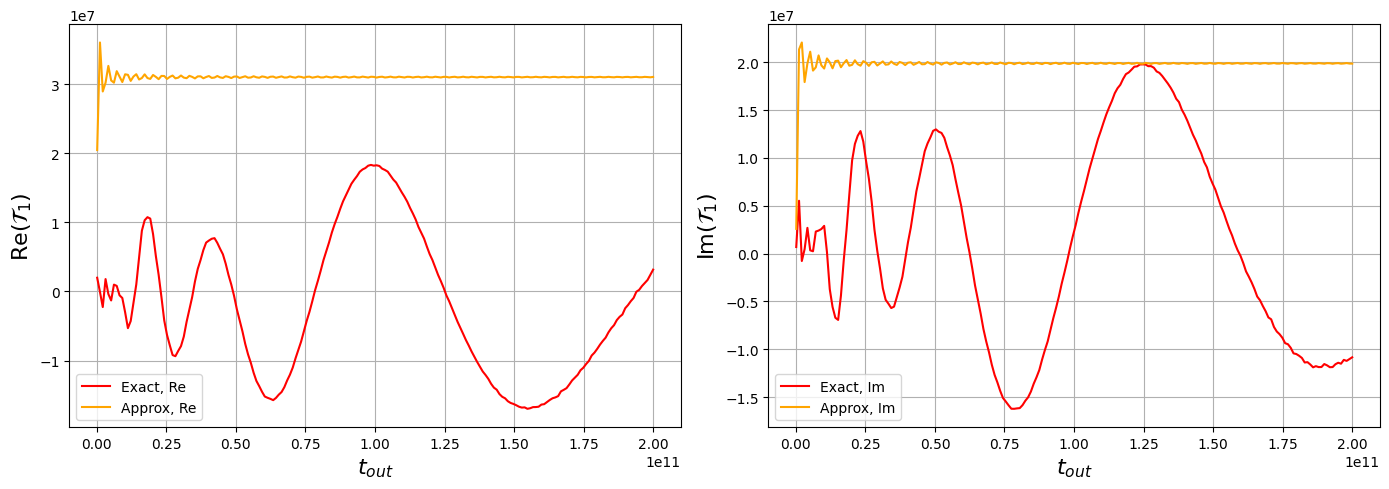

In [29]:
import numpy as np
import matplotlib.pyplot as plt

tspec = np.linspace (1.32e8, 2e11, 200)
t_spec = [1.32e8, 1e9]  
# Sweep over tspec and collect errors
tint0_error_list = []
tint1_error_list = []
tint0_error_list_2 = []
tint1_error_list_2 = []
tint0_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())[0][1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li , sf, lf, kp*rho_H)) for T in tspec]

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())[0][0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]

for T in tspec:
    _, _, tint0_error, _, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    _, tint1_error, _, _, _,= TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    tint0_error_list.append(tint0_error.item() if hasattr(tint0_error, 'item') else float(tint0_error))
    tint1_error_list.append(tint1_error.item() if hasattr(tint1_error, 'item') else float(tint1_error))

    _, _, _, _,tint0_error_2 = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    _, _, _,tint1_error_2, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.GaussLegendre())
    tint0_error_list_2.append(tint0_error_2.item() if hasattr(tint0_error_2, 'item') else float(tint0_error_2))
    tint1_error_list_2.append(tint1_error_2.item() if hasattr(tint1_error_2, 'item') else float(tint1_error_2))
    #print("Estimated error for tint1_Texact:", tint1_error)
    #print("Estimated error for tint0_Texact:", tint0_error)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Первый график
ax1.plot(tspec, tint0_error_list, label='Integration error for $\\mathcal{T}_0$')
ax1.plot(tspec, tint1_error_list, label='Integration error for $\\mathcal{T}_1$', color='red')
ax1.set_xlabel('$t_{out}$', fontsize=16)
ax1.set_ylabel('Integration error GaussianLegendre', fontsize=16)
ax1.grid()
ax1.legend()
ax1.set_title('Errors (N=101 vs N=201)')

# Второй график
ax2.plot(tspec, tint0_error_list_2, label='Integration error for $\\mathcal{T}_0$ (2)')
ax2.plot(tspec, tint1_error_list_2, label='Integration error for $\\mathcal{T}_1$ (2)', color='red')
ax2.set_xlabel('$t_{out}$', fontsize=16)
ax2.set_ylabel('Integration error GaussianLegendre (2)', fontsize=16)
ax2.grid()
ax2.legend()
ax2.set_title('Abs Errors (N=201) - Errors (N=101)/ Abs Errors (N=201)')

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint0_Texact).real, label='Exact, Re')
ax1.plot(tspec, np.array(tint0).real, label='Approx, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_0$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint0_Texact).imag, label='Exact, Im')
ax2.plot(tspec, np.array(tint0).imag, label='Approx, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_0$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact).real, label='Exact, Re', color = 'red')
ax1.plot(tspec, np.array(tint1).real, label='Approx, Re', color = 'orange')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact).imag, label='Exact, Im', color = 'red')
ax2.plot(tspec, np.array(tint1).imag, label='Approx, Im', color = 'orange')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()


/home/ulyana/Itmo/.venv/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


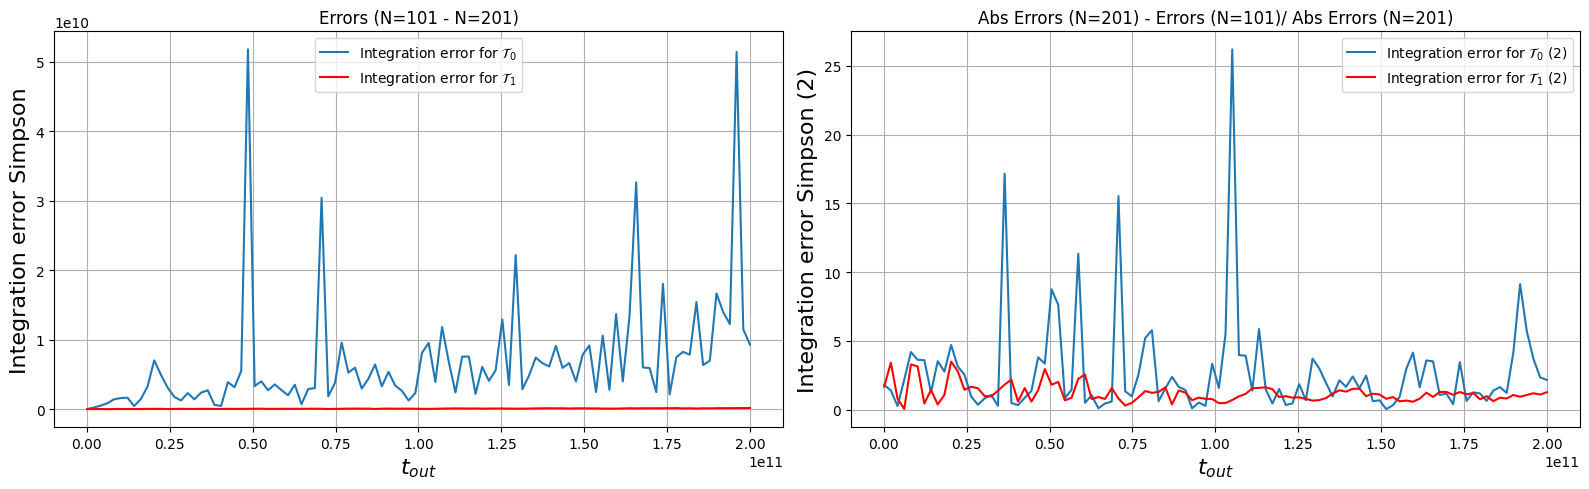

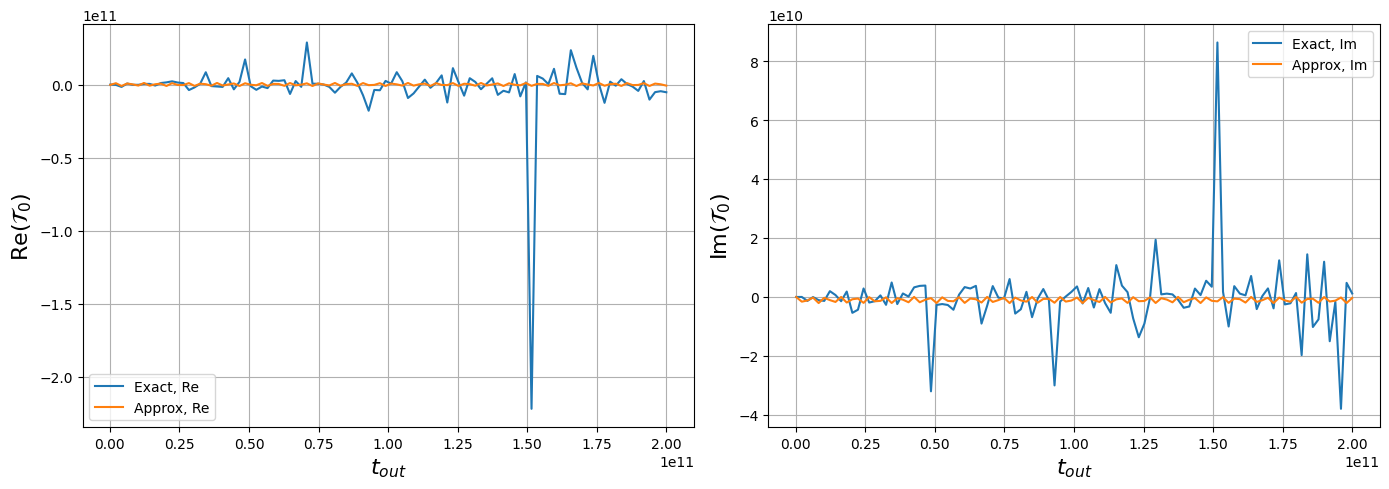

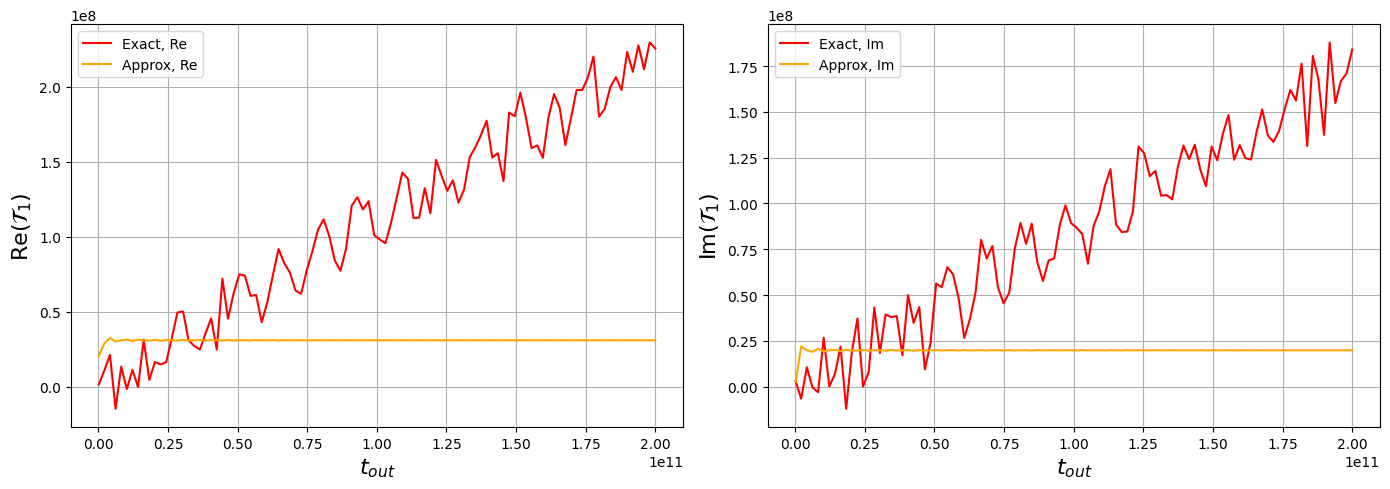

In [28]:
tspec = np.linspace (1.32e8, 2e11, 100)
t_spec = [1.32e8, 1e9]  
# Sweep over tspec and collect errors
tint0_error_list = []
tint1_error_list = []
tint0_error_list_2 = []
tint1_error_list_2 = []

tint0_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())[0][1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li , sf, lf, kp*rho_H)) for T in tspec]

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())[0][0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]


for T in tspec:
    _, _, tint0_error, _, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    _, tint1_error, _, _, _,= TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    tint0_error_list.append(tint0_error.item() if hasattr(tint0_error, 'item') else float(tint0_error))
    tint1_error_list.append(tint1_error.item() if hasattr(tint1_error, 'item') else float(tint1_error))

    _, _, _, _,tint0_error_2 = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    _, _, _,tint1_error_2, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    tint0_error_list_2.append(tint0_error_2.item() if hasattr(tint0_error_2, 'item') else float(tint0_error_2))
    tint1_error_list_2.append(tint1_error_2.item() if hasattr(tint1_error_2, 'item') else float(tint1_error_2))
    #print("Estimated error for tint1_Texact:", tint1_error)
    #print("Estimated error for tint0_Texact:", tint0_error)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Первый график
ax1.plot(tspec, tint0_error_list, label='Integration error for $\\mathcal{T}_0$')
ax1.plot(tspec, tint1_error_list, label='Integration error for $\\mathcal{T}_1$', color='red')
ax1.set_xlabel('$t_{out}$', fontsize=16)
ax1.set_ylabel('Integration error Simpson', fontsize=16)
ax1.grid()
ax1.legend()
ax1.set_title('Errors (N=101 - N=201)')

# Второй график
ax2.plot(tspec, tint0_error_list_2, label='Integration error for $\\mathcal{T}_0$ (2)')
ax2.plot(tspec, tint1_error_list_2, label='Integration error for $\\mathcal{T}_1$ (2)', color='red')
ax2.set_xlabel('$t_{out}$', fontsize=16)
ax2.set_ylabel('Integration error Simpson (2)', fontsize=16)
ax2.grid()
ax2.legend()
ax2.set_title('Abs Errors (N=201) - Errors (N=101)/ Abs Errors (N=201)')

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint0_Texact).real, label='Exact, Re')
ax1.plot(tspec, np.array(tint0).real, label='Approx, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_0$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint0_Texact).imag, label='Exact, Im')
ax2.plot(tspec, np.array(tint0).imag, label='Approx, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_0$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact).real, label='Exact, Re', color = 'red')
ax1.plot(tspec, np.array(tint1).real, label='Approx, Re', color = 'orange')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact).imag, label='Exact, Im', color = 'red')
ax2.plot(tspec, np.array(tint1).imag, label='Approx, Im', color = 'orange')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

/home/ulyana/Itmo/.venv/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


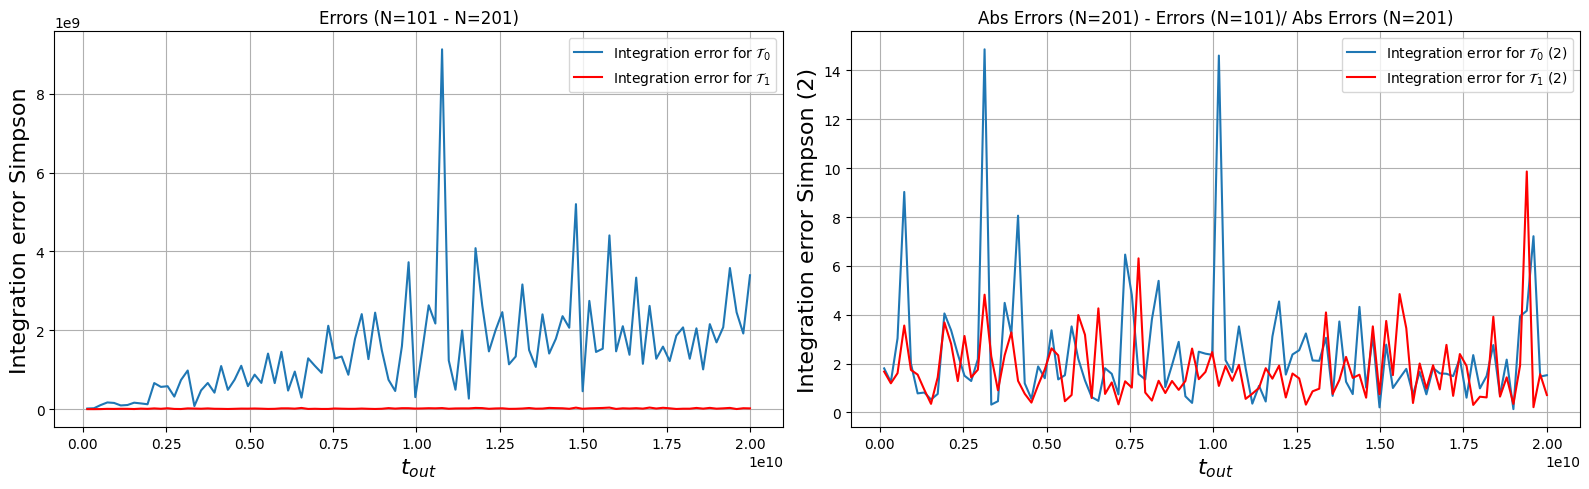

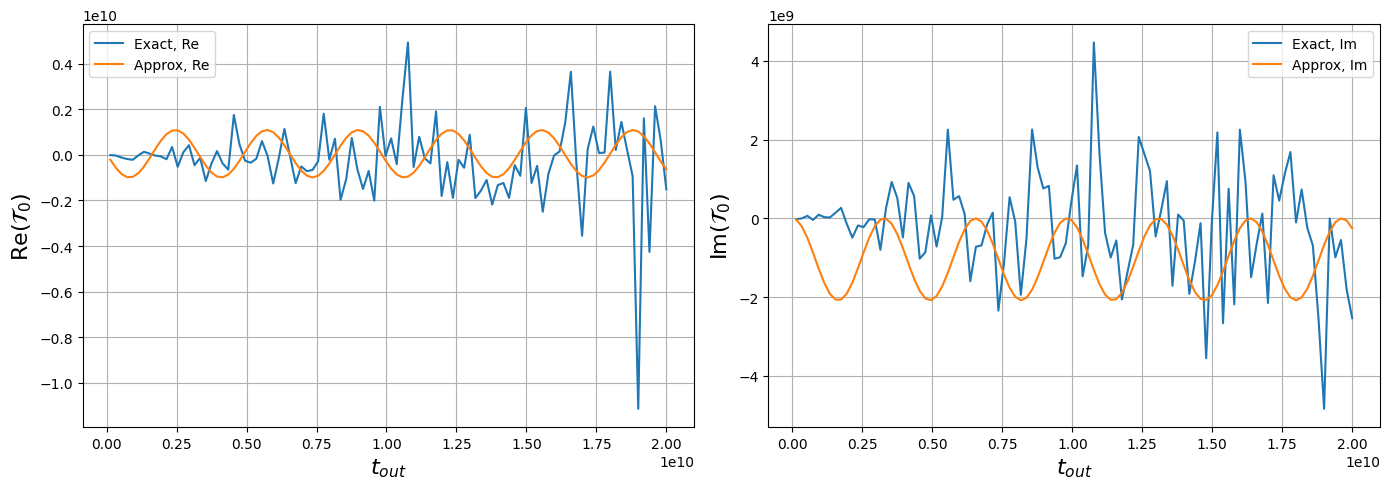

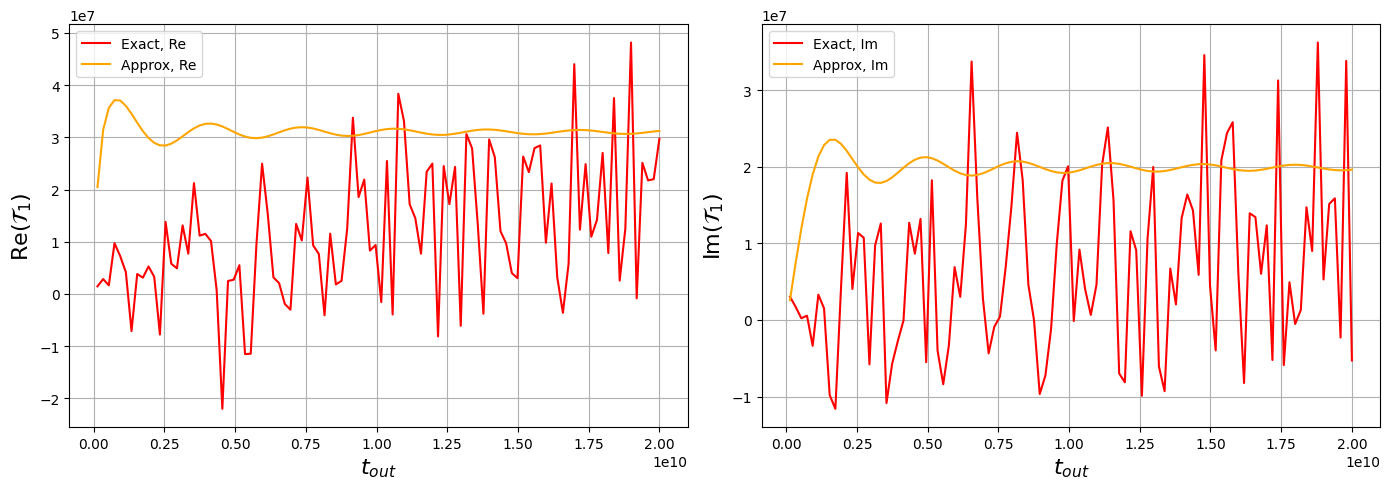

In [27]:
tspec = np.linspace (1.32e8, 2e10, 100)
t_spec = [1.32e8, 1e9]  
# Sweep over tspec and collect errors
tint0_error_list = []
tint1_error_list = []
tint0_error_list_2 = []
tint1_error_list_2 = []

tint0_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())[0][1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li , sf, lf, kp*rho_H)) for T in tspec]

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())[0][0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]


for T in tspec:
    _, _, tint0_error, _, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    _, tint1_error, _, _, _,= TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    tint0_error_list.append(tint0_error.item() if hasattr(tint0_error, 'item') else float(tint0_error))
    tint1_error_list.append(tint1_error.item() if hasattr(tint1_error, 'item') else float(tint1_error))

    _, _, _, _,tint0_error_2 = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    _, _, _,tint1_error_2, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Simpson())
    tint0_error_list_2.append(tint0_error_2.item() if hasattr(tint0_error_2, 'item') else float(tint0_error_2))
    tint1_error_list_2.append(tint1_error_2.item() if hasattr(tint1_error_2, 'item') else float(tint1_error_2))
    #print("Estimated error for tint1_Texact:", tint1_error)
    #print("Estimated error for tint0_Texact:", tint0_error)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Первый график
ax1.plot(tspec, tint0_error_list, label='Integration error for $\\mathcal{T}_0$')
ax1.plot(tspec, tint1_error_list, label='Integration error for $\\mathcal{T}_1$', color='red')
ax1.set_xlabel('$t_{out}$', fontsize=16)
ax1.set_ylabel('Integration error Simpson', fontsize=16)
ax1.grid()
ax1.legend()
ax1.set_title('Errors (N=101 - N=201)')

# Второй график
ax2.plot(tspec, tint0_error_list_2, label='Integration error for $\\mathcal{T}_0$ (2)')
ax2.plot(tspec, tint1_error_list_2, label='Integration error for $\\mathcal{T}_1$ (2)', color='red')
ax2.set_xlabel('$t_{out}$', fontsize=16)
ax2.set_ylabel('Integration error Simpson (2)', fontsize=16)
ax2.grid()
ax2.legend()
ax2.set_title('Abs Errors (N=201) - Errors (N=101)/ Abs Errors (N=201)')

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint0_Texact).real, label='Exact, Re')
ax1.plot(tspec, np.array(tint0).real, label='Approx, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_0$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint0_Texact).imag, label='Exact, Im')
ax2.plot(tspec, np.array(tint0).imag, label='Approx, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_0$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact).real, label='Exact, Re', color = 'red')
ax1.plot(tspec, np.array(tint1).real, label='Approx, Re', color = 'orange')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact).imag, label='Exact, Im', color = 'red')
ax2.plot(tspec, np.array(tint1).imag, label='Approx, Im', color = 'orange')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

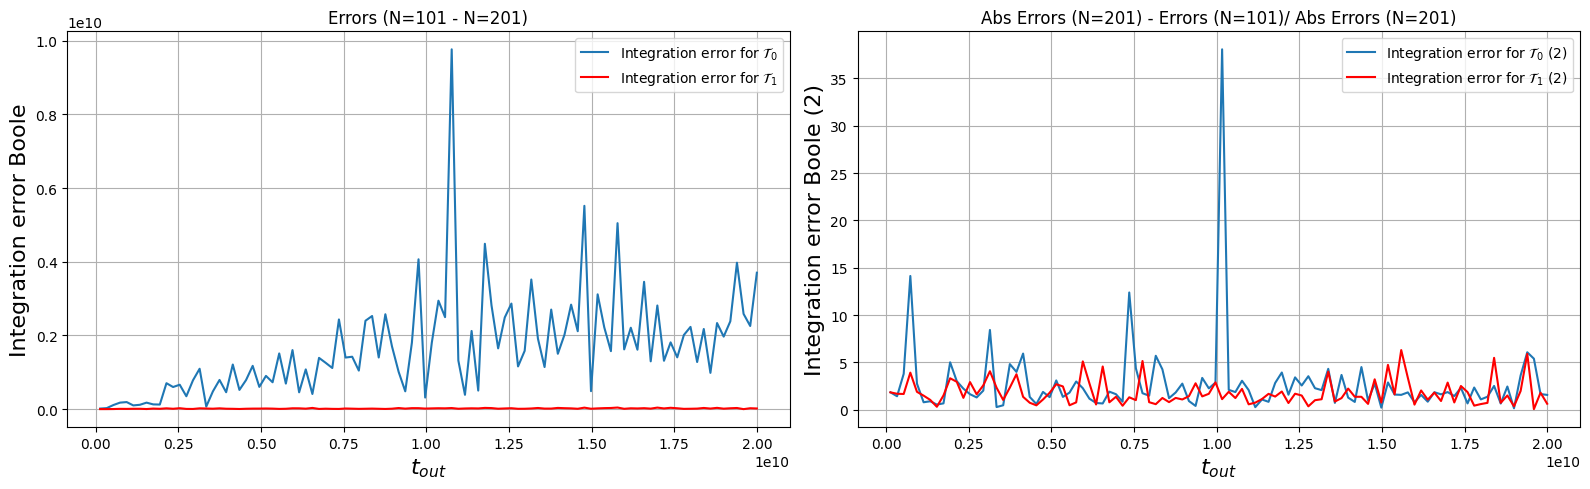

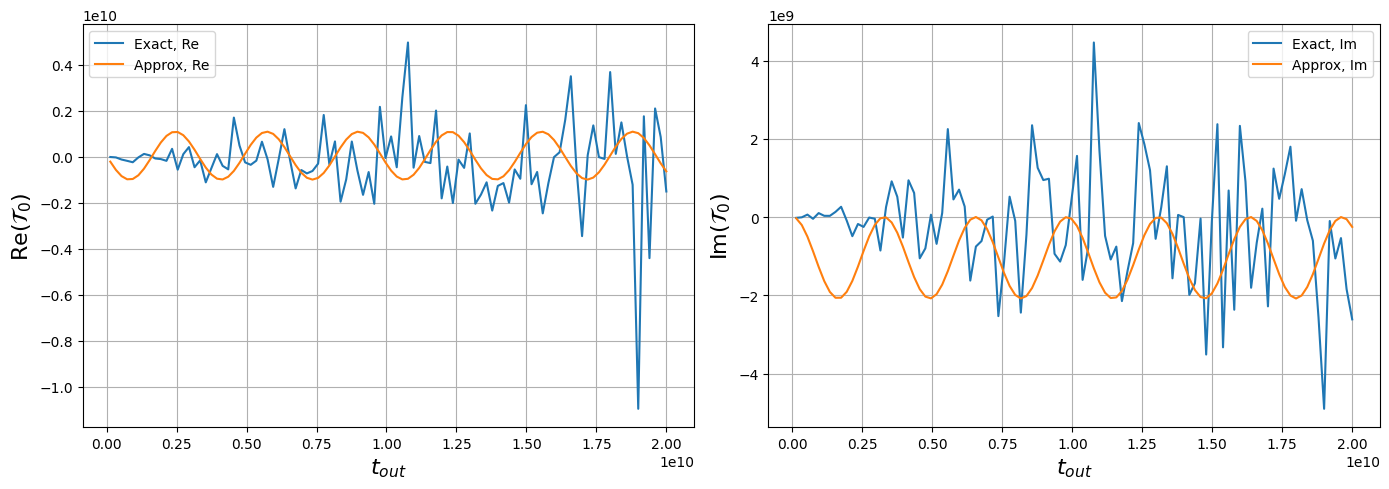

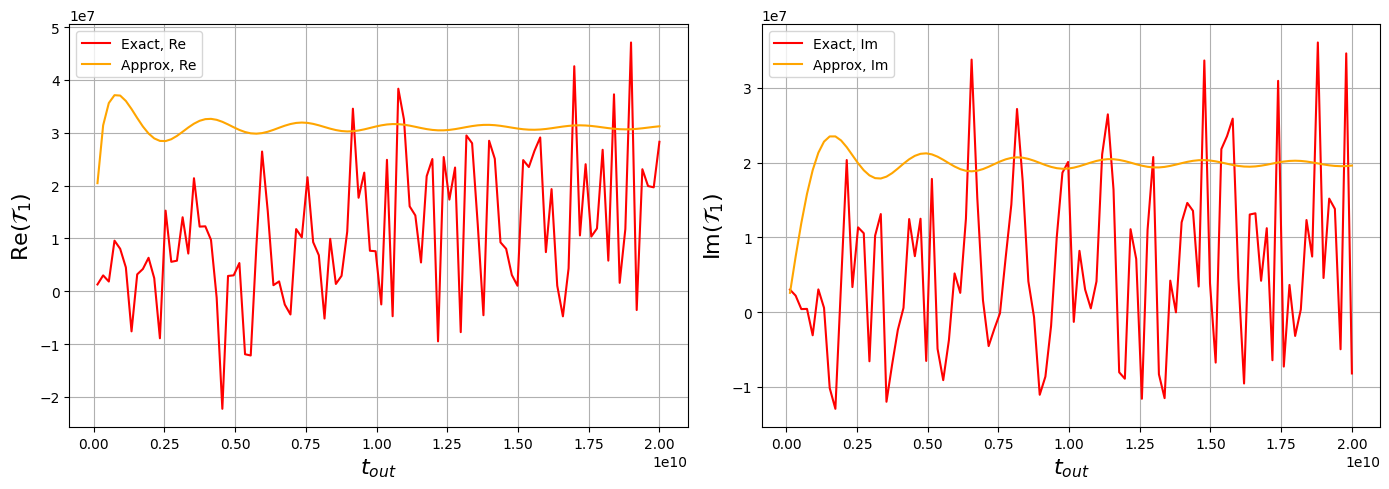

In [26]:
tspec = np.linspace (1.32e8, 2e10, 100)
t_spec = [1.32e8, 1e9]  
# Sweep over tspec and collect errors
tint0_error_list = []
tint1_error_list = []
tint0_error_list_2 = []
tint1_error_list_2 = []

tint0_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Boole())[0][1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li , sf, lf, kp*rho_H)) for T in tspec]

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Boole())[0][0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]


for T in tspec:
    _, _, tint0_error, _, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Boole())
    _, tint1_error, _, _, _,= TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Boole())
    tint0_error_list.append(tint0_error.item() if hasattr(tint0_error, 'item') else float(tint0_error))
    tint1_error_list.append(tint1_error.item() if hasattr(tint1_error, 'item') else float(tint1_error))

    _, _, _, _,tint0_error_2 = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Boole())
    _, _, _,tint1_error_2, _, = TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T, torchquad.Boole())
    tint0_error_list_2.append(tint0_error_2.item() if hasattr(tint0_error_2, 'item') else float(tint0_error_2))
    tint1_error_list_2.append(tint1_error_2.item() if hasattr(tint1_error_2, 'item') else float(tint1_error_2))
    #print("Estimated error for tint1_Texact:", tint1_error)
    #print("Estimated error for tint0_Texact:", tint0_error)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Первый график
ax1.plot(tspec, tint0_error_list, label='Integration error for $\\mathcal{T}_0$')
ax1.plot(tspec, tint1_error_list, label='Integration error for $\\mathcal{T}_1$', color='red')
ax1.set_xlabel('$t_{out}$', fontsize=16)
ax1.set_ylabel('Integration error Boole', fontsize=16)
ax1.grid()
ax1.legend()
ax1.set_title('Errors (N=101 - N=201)')

# Второй график
ax2.plot(tspec, tint0_error_list_2, label='Integration error for $\\mathcal{T}_0$ (2)')
ax2.plot(tspec, tint1_error_list_2, label='Integration error for $\\mathcal{T}_1$ (2)', color='red')
ax2.set_xlabel('$t_{out}$', fontsize=16)
ax2.set_ylabel('Integration error Boole (2)', fontsize=16)
ax2.grid()
ax2.legend()
ax2.set_title('Abs Errors (N=201) - Errors (N=101)/ Abs Errors (N=201)')

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint0_Texact).real, label='Exact, Re')
ax1.plot(tspec, np.array(tint0).real, label='Approx, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_0$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint0_Texact).imag, label='Exact, Im')
ax2.plot(tspec, np.array(tint0).imag, label='Approx, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_0$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact).real, label='Exact, Re', color = 'red')
ax1.plot(tspec, np.array(tint1).real, label='Approx, Re',  color = 'orange')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact).imag, label='Exact, Im', color = 'red')
ax2.plot(tspec, np.array(tint1).imag, label='Approx, Im', color = 'orange')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()